In [ ]:
# 1. Upserting
# 2. Retrival 
# 3. Augment
# 4. Generation

In [ ]:
# !pip install -q pinecone sentence-transformers beautifulsoup4 \
#                langchain langchain-openai langgraph python-dotenv

In [ ]:
import os
from pathlib import Path
from typing import TypedDict
from dotenv import load_dotenv
from bs4 import BeautifulSoup
from sentence_transformers import SentenceTransformer
from pinecone import Pinecone, ServerlessSpec
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END

load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
print("✅ Ready")

✅ Ready


In [ ]:
# llm = ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash",
#     api_key="   --  "
# )

In [ ]:
HTML_DIR   = Path("coffee_pages")
INDEX_NAME = "naive-rag-coffee-v1"       # fresh index — chunks, not full docs
EMBED_DIM  = 384
TOP_K      = 3

embedder = SentenceTransformer("paraphrase-MiniLM-L6-v2")
llm      = ChatOpenAI(model="gpt-4o-mini", temperature=0)
pc       = Pinecone(api_key=os.getenv("PINECONE_API_KEY"))

print(f"✅ Embedding dim : {EMBED_DIM}")
print(f"   Index name    : {INDEX_NAME}")

✅ Embedding dim : 384
   Index name    : naive-rag-coffee-v1


---
# PART 1 — UPSERT

## Step 1 — Extract Section Chunks from HTML

Each HTML file has clearly defined `<section>` tags with `<h2>` headings:
Overview, Ingredients, Method, Variations, Flavor Profile, Benefits, Cultural Notes, FAQ.

We use BeautifulSoup to extract each section as a separate chunk.

**Every chunk carries its parent document's metadata:**
- `coffee_name` → which coffee this chunk belongs to (from the `<h1>` tag)
- `section` → which part of the document (Ingredients, Benefits, etc.)
- `file_name` → source file for traceability

Without this, a chunk saying *"warm the milk gently"* has no context about which coffee it refers to.

In [ ]:
def extract_chunks(html_path: Path) -> list[dict]:
    """Split one HTML file into section-level chunks.
    Each chunk carries metadata so it knows which document it came from.
    """
    soup = BeautifulSoup(html_path.read_text(encoding="utf-8"), "html.parser")

    # Coffee name from <h1>, e.g. "Ashwagandha Coffee (Adaptogenic Latte)"
    coffee_name = soup.find("h1").get_text(strip=True)

    chunks = []
    for section in soup.find_all("section"):
        heading = section.find("h2")
        text    = section.get_text(separator=" ", strip=True)

        if not text:
            continue

        chunks.append({
            "text"        : text,
            "coffee_name" : coffee_name,
            "section"     : heading.get_text(strip=True) if heading else "General",
            "file_name"   : html_path.name,
        })

    return chunks


# Run over all HTML files
all_chunks = []
for fp in sorted(HTML_DIR.glob("*.html")):
    all_chunks.extend(extract_chunks(fp))

print(f"✅ {len(list(HTML_DIR.glob('*.html')))} files → {len(all_chunks)} chunks")

✅ 5 files → 40 chunks


In [ ]:
# Show 3 chunks from the first file
first_file = sorted(HTML_DIR.glob("*.html"))[0].name
sample     = [c for c in all_chunks if c["file_name"] == first_file][:3]

for c in sample:
    print(f"☕ Coffee  : {c['coffee_name']}")
    print(f"📌 Section : {c['section']}")
    print(f"📄 Text    : {c['text'][:200]}")
    print("─" * 55)

☕ Coffee  : Ashwagandha Coffee (Adaptogenic Latte)
📌 Section : Overview
📄 Text    : Overview Ashwagandha coffee combines roasted coffee with powdered ashwagandha, an herb widely used in Indian traditions. The goal is to enjoy a familiar cup while layering in earthy, slightly bitter h
───────────────────────────────────────────────────────
☕ Coffee  : Ashwagandha Coffee (Adaptogenic Latte)
📌 Section : Ingredients (Base & Optional)
📄 Text    : Ingredients (Base & Optional) 1 cup milk of choice (dairy or plant-based) ½–1 tsp instant coffee or a single espresso shot ¼–½ tsp ashwagandha powder (culinary grade) ¼ tsp cinnamon or cardamom (optio
───────────────────────────────────────────────────────
☕ Coffee  : Ashwagandha Coffee (Adaptogenic Latte)
📌 Section : Method
📄 Text    : Method Warm the milk gently; avoid boiling when using delicate plant milks. Brew coffee (espresso, Moka pot, or dissolve instant in a little hot water). Whisk ashwagandha into the warm milk until ther
──────────────

In [ ]:
texts      = [c["text"] for c in all_chunks]
embeddings = embedder.encode(texts, normalize_embeddings=True, show_progress_bar=True)

print(f"✅ {len(embeddings)} embeddings — shape: {embeddings.shape}")

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

✅ 40 embeddings — shape: (40, 384)


In [ ]:
# Create index if it doesn't exist
if INDEX_NAME not in [i.name for i in pc.list_indexes()]:
    pc.create_index(
        name      = INDEX_NAME,
        dimension = EMBED_DIM,
        metric    = "dotproduct",
        spec      = ServerlessSpec(cloud="aws", region="us-east-1")
    )

index = pc.Index(host=pc.describe_index(INDEX_NAME).host)
print(f"✅ Connected to '{INDEX_NAME}'")

✅ Connected to 'naive-rag-coffee-v1'


In [ ]:
vectors = []
for i, chunk in enumerate(all_chunks):
    # Human-readable ID: filename + section
    vec_id = f"{chunk['file_name']}_{chunk['section']}".replace(" ", "_")
    vectors.append({
        "id"     : vec_id,
        "values" : embeddings[i].tolist(),
        "metadata": {
            "text"        : chunk["text"],
            "coffee_name" : chunk["coffee_name"],
            "section"     : chunk["section"],
            "file_name"   : chunk["file_name"],
        }
    })

# Upsert in batches of 100 (Pinecone best practice)
for i in range(0, len(vectors), 100):
    index.upsert(vectors=vectors[i:i+100])

print(f"✅ Upserted {len(vectors)} chunks")
print(index.describe_index_stats())

✅ Upserted 40 chunks
{'dimension': 384,
 'index_fullness': 0.0,
 'metric': 'dotproduct',
 'namespaces': {'': {'vector_count': 40}},
 'total_vector_count': 40,
 'vector_type': 'dense'}


In [ ]:
test  = "What are the ingredients in Ashwagandha Coffee?"
q_vec = embedder.encode([test], normalize_embeddings=True)[0].tolist()
hits  = index.query(vector=q_vec, top_k=3, include_metadata=True)

print(f"🔍 '{test}'\n")
for m in hits.matches:
    print(f"Score {m.score:.3f} | {m.metadata['coffee_name']} › {m.metadata['section']}")
    print(f"  {m.metadata['text'][:180]}...\n")

🔍 'What are the ingredients in Ashwagandha Coffee?'

Score 0.837 | Ashwagandha Coffee (Adaptogenic Latte) › Overview
  Overview Ashwagandha coffee combines roasted coffee with powdered ashwagandha, an herb widely used in Indian traditions. The goal is to enjoy a familiar cup while layering in earth...

Score 0.731 | Ashwagandha Coffee (Adaptogenic Latte) › Method
  Method Warm the milk gently; avoid boiling when using delicate plant milks. Brew coffee (espresso, Moka pot, or dissolve instant in a little hot water). Whisk ashwagandha into the ...

Score 0.678 | Ashwagandha Coffee (Adaptogenic Latte) › Ingredients (Base & Optional)
  Ingredients (Base & Optional) 1 cup milk of choice (dairy or plant-based) ½–1 tsp instant coffee or a single espresso shot ¼–½ tsp ashwagandha powder (culinary grade) ¼ tsp cinnamo...



In [ ]:
# RAG Using LangGrpah

# 1) Nodes --> Retriver & Generation
# 2) Edges --> Retriver to generation ... generation to end
# 3) States --> retrived Answer , Final answer , user query  

In [ ]:
class RAGState(TypedDict):
    query          : str    # user's question
    retrieved_docs : list   # Pinecone matches — filled by retrieve_node
    answer         : str    # final answer  — filled by generate_node

In [ ]:
# Retriver node
def retrieve_node(state: RAGState) -> dict:
    q_vec  = embedder.encode([state["query"]], normalize_embeddings=True)[0].tolist()
    result = index.query(vector=q_vec, top_k=TOP_K, include_metadata=True)
    print(f"🔍 Retrieved: {[m.metadata['coffee_name'] + ' › ' + m.metadata['section'] for m in result.matches]}")
    return {"retrieved_docs": result.matches}

In [ ]:
def generate_node(state: RAGState) -> dict:
    # Build context — label each chunk so LLM knows source
    context = ""
    for m in state["retrieved_docs"]:
        label    = f"{m.metadata['coffee_name']} › {m.metadata['section']}"
        context += f"[{label}]\n{m.metadata['text']}\n\n"

    prompt = f"""You are a coffee expert. Answer using ONLY the context below.
If the context doesn't contain the answer, say so clearly.

CONTEXT:
{context}
QUESTION: {state['query']}
ANSWER:"""

    return {"answer": llm.invoke(prompt).content}

In [ ]:
builder = StateGraph(RAGState)

builder.add_node("retrieve", retrieve_node)
builder.add_node("generate", generate_node)

builder.add_edge(START,      "retrieve")
builder.add_edge("retrieve", "generate")
builder.add_edge("generate", END)

rag_graph = builder.compile()
print("✅ Graph: START → retrieve → generate → END")

✅ Graph: START → retrieve → generate → END


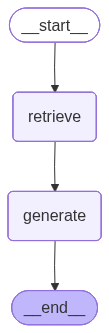

In [ ]:
rag_graph

In [ ]:
def run(query):
    print(f"\n{'='*55}\n❓ {query}\n{'='*55}")
    result = rag_graph.invoke({"query": query, "retrieved_docs": [], "answer": ""})
    print(f"\n💬 {result['answer']}")
    return result

In [ ]:
r1 = run("What are the ingredients in Masala Coffee?")


❓ What are the ingredients in Masala Coffee?
🔍 Retrieved: ['Masala Coffee (Spiced Indian Coffee) › Variations & Regional Twists', 'Masala Coffee (Spiced Indian Coffee) › Overview', 'Masala Coffee (Spiced Indian Coffee) › Cultural & Historical Notes']

💬 The ingredients in Masala Coffee typically include brewed coffee and classic Indian spices such as cardamom, cinnamon, clove, nutmeg, and black pepper.


In [ ]:
r1['query']

'What are the ingredients in Masala Coffee?'

In [ ]:
r1['retrieved_docs']

[{'id': '02_masala_coffee_spiced_indian_coffee.html_Variations_&_Regional_Twists',
  'metadata': {'coffee_name': 'Masala Coffee (Spiced Indian Coffee)',
               'file_name': '02_masala_coffee_spiced_indian_coffee.html',
               'section': 'Variations & Regional Twists',
               'text': 'Variations & Regional Twists Iced masala coffee: chill '
                       'infusion and coffee, then pour over ice. Vegan: use oat '
                       'or almond milk; add a dash of vanilla. Festive: add a '
                       'pinch of saffron or rose water.'},
  'score': 0.720010757,
  'values': []},
 {'id': '02_masala_coffee_spiced_indian_coffee.html_Overview',
  'metadata': {'coffee_name': 'Masala Coffee (Spiced Indian Coffee)',
               'file_name': '02_masala_coffee_spiced_indian_coffee.html',
               'section': 'Overview',
               'text': 'Overview Masala coffee infuses classic Indian spices '
                       'into brewed coffee. Card

In [ ]:
r1['answer']

'The ingredients in Masala Coffee typically include brewed coffee and classic Indian spices such as cardamom, cinnamon, clove, nutmeg, and black pepper.'

In [ ]:
r2 = run("Which coffee is best for someone who wants health benefits over caffeine?")


❓ Which coffee is best for someone who wants health benefits over caffeine?
🔍 Retrieved: ['Beaten Coffee (Phenti Hui Coffee) › Overview', 'Turmeric Coffee (Haldi Cappuccino) › Cultural & Historical Notes', 'Ashwagandha Coffee (Adaptogenic Latte) › Overview']

💬 The context does not contain the answer to which coffee is best for someone who wants health benefits over caffeine.


In [ ]:
r3 = run(
    "My friend lives in Shimla right now. She loves Indian flavors and prefers "
    "health benefits over caffeine. What coffee should I gift her and how should "
    "she prepare it for her current weather?"
)

## Drawbacks of Native Rag

## 1) We can show info only the upserted data nothing outside outside of it
## 2) Feedback loop
## 3) Reasoning & Planning 

In [ ]:
## Segerating the question 
### 1) Place shimla --> weather 
### 2) 